In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
 

In [2]:
sns.set_style('whitegrid')
season_order = ['Kharif', 'Rabi', 'Zaid']

        Yield_Tonnes_Ha  Revenue_INR  Total_Cost_INR  Profit_INR
Season                                                          
Kharif             5.64    710719.06       531804.41   178914.65
Rabi               5.08    601526.05       513836.58    87689.47
Zaid               4.67    519171.90       543976.73   -24804.82


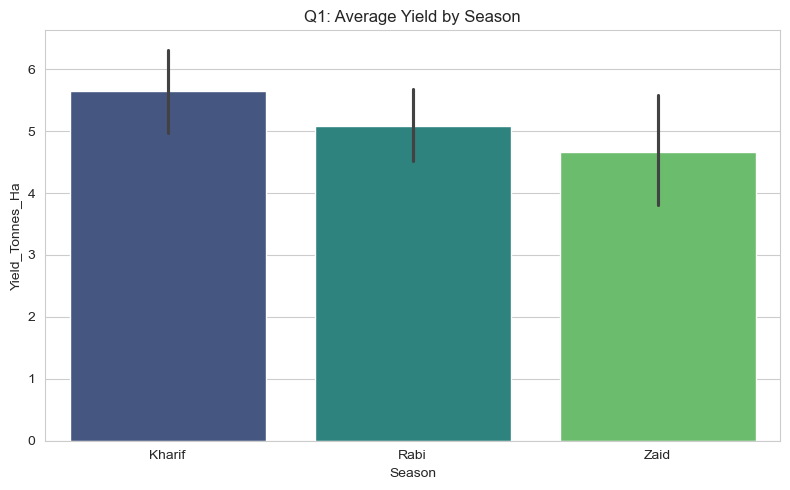

In [5]:
perf_cols = ['Yield_Tonnes_Ha', 'Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
print(df.groupby('Season')[perf_cols].mean().reindex(season_order).round(2))
 
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, hue='Season',
            palette='viridis', ax=ax, legend=False)
ax.set_title('Q1: Average Yield by Season')
plt.tight_layout(); plt.show()

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Soil_Moisture_pct  \
Season                                                                    
Kharif       852.08              28.45         71.81              31.20   
Rabi         436.00              23.49         57.89              24.05   
Zaid         299.42              31.04         52.01              19.17   

        Sunlight_Hours_Day  
Season                      
Kharif                6.79  
Rabi                  7.59  
Zaid                  8.18  


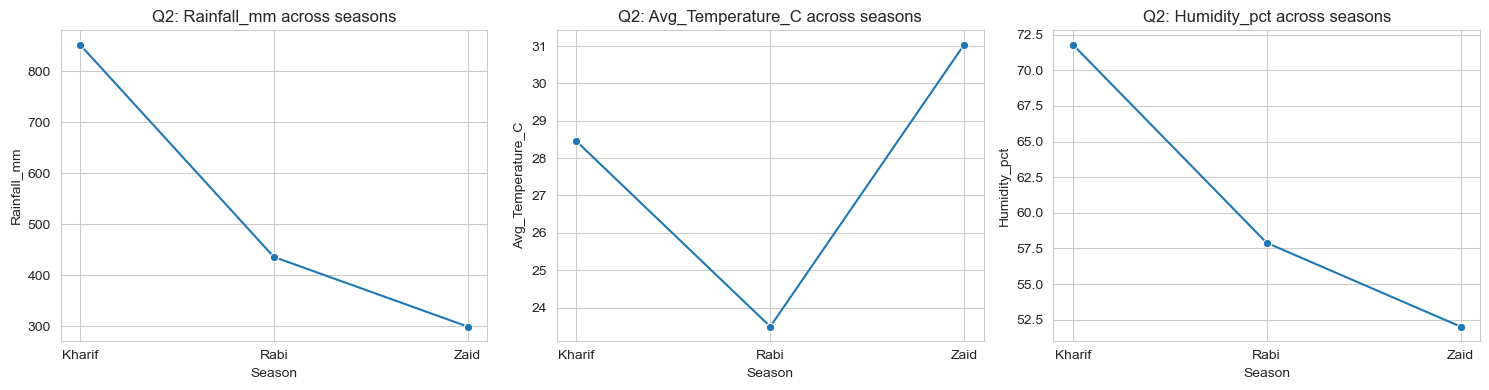

In [6]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct', 'Sunlight_Hours_Day']
print(df.groupby('Season')[env_cols].mean().reindex(season_order).round(2))
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']):
    sns.lineplot(data=df.groupby('Season')[col].mean().reindex(season_order), marker='o', ax=ax)
    ax.set_title(f'Q2: {col} across seasons')
plt.tight_layout(); plt.show()
 

In [7]:
all_numeric = df.select_dtypes(include=np.number).columns.tolist()
season_means = df.groupby('Season')[all_numeric].mean().reindex(season_order)
pct_range = ((season_means.max() - season_means.min()) / season_means.mean() * 100).sort_values(ascending=False)
print("Characteristics ranked by relative variation across seasons (%):")
print(pct_range.round(1))
 

Characteristics ranked by relative variation across seasons (%):
Profit_INR                       252.8
Rainfall_mm                      104.4
Soil_Moisture_pct                 48.5
Disease_Pest_Risk_pct             36.6
Humidity_pct                      32.7
Revenue_INR                       31.4
Water_Efficiency_t_per_1000m3     28.6
Avg_Temperature_C                 27.3
Yield_Tonnes_Ha                   19.1
Sunlight_Hours_Day                18.4
Production_Tonnes                 17.6
Water_Used_m3                      9.4
Total_Cost_INR                     5.7
Farm_Area_Hectares                 4.3
Pesticide_Litre_ha                 2.9
Market_Price_INR_Tonne             1.4
Potassium_kg_ha                    1.4
Phosphorus_kg_ha                   1.4
Fertilizer_kg_ha                   1.3
Seed_Quality_Score                 1.3
Soil_pH                            0.8
Nitrogen_kg_ha                     0.4
dtype: float64


Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             22.8   33.2     26.0       18.0
Rabi               22.7   32.3     26.9       18.0
Zaid               23.6   32.7     23.6       20.2
Season     Kharif  Rabi  Zaid
Crop                         
Chilli        185   163    64
Cotton        215   201    92
Groundnut     193   177    54
Maize         234   233    84
Pulses        221   213    62
Rice          314   274   102
Sugarcane     125   129    51
Wheat         292   237    85


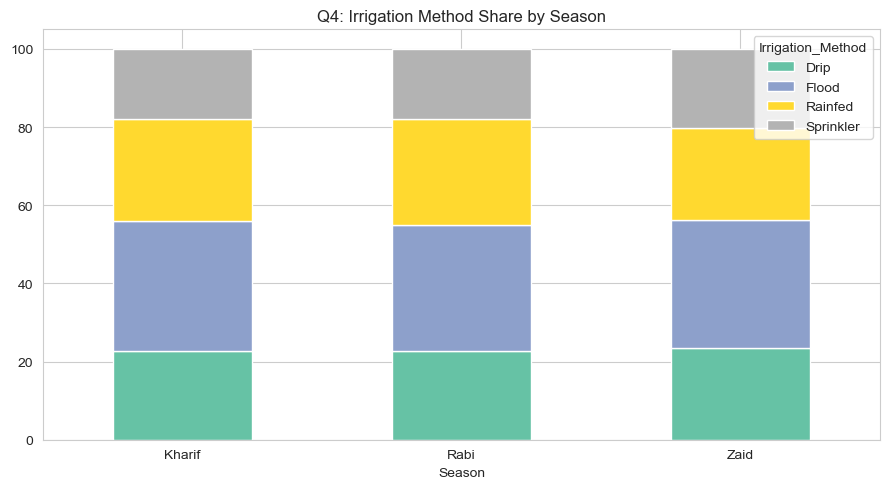

In [8]:
irrigation_pct = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').reindex(season_order) * 100
print(irrigation_pct.round(1))
 
crop_season = pd.crosstab(df['Crop'], df['Season'])[season_order]
print(crop_season)
 
fig, ax = plt.subplots(figsize=(9, 5))
irrigation_pct.plot(kind='bar', stacked=True, colormap='Set2', ax=ax)
ax.set_title('Q4: Irrigation Method Share by Season')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3  Nitrogen_kg_ha  \
Season                                                                        
Kharif            187.08                5.08        6102.20          120.02   
Rabi              185.41                5.02        5846.99          120.40   
Zaid              184.64                5.17        6419.89          120.53   

        Phosphorus_kg_ha  Potassium_kg_ha  
Season                                     
Kharif             58.10           105.30  
Rabi               57.31           103.93  
Zaid               58.13           105.42  


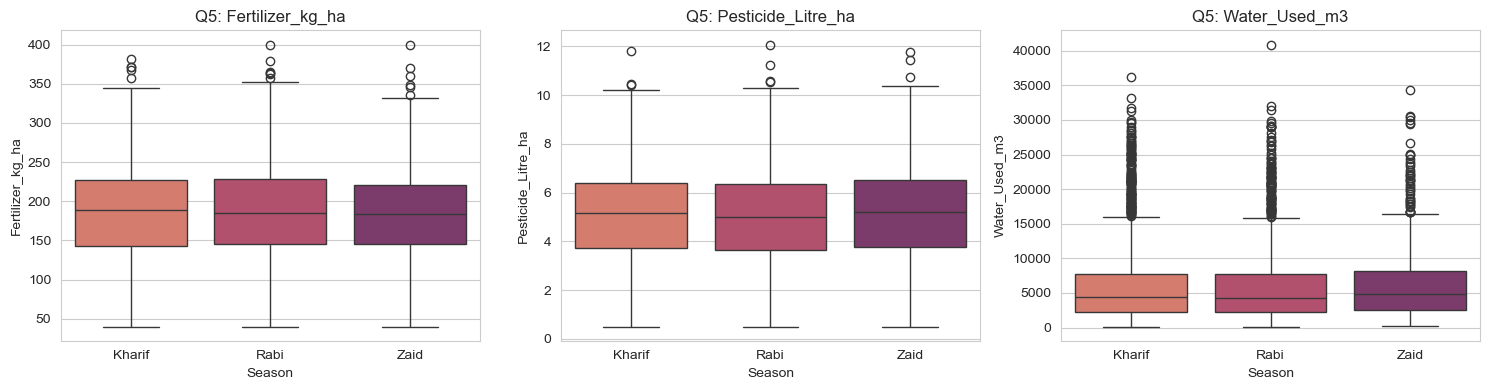

In [9]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3',
                  'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']
print(df.groupby('Season')[resource_cols].mean().reindex(season_order).round(2))
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3']):
    sns.boxplot(data=df, x='Season', y=col, order=season_order, hue='Season',
                palette='flare', ax=ax, legend=False)
    ax.set_title(f'Q5: {col}')
plt.tight_layout(); plt.show()

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Profit_INR                       0.489822
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Name: Yield_Tonnes_Ha, dtype: float64


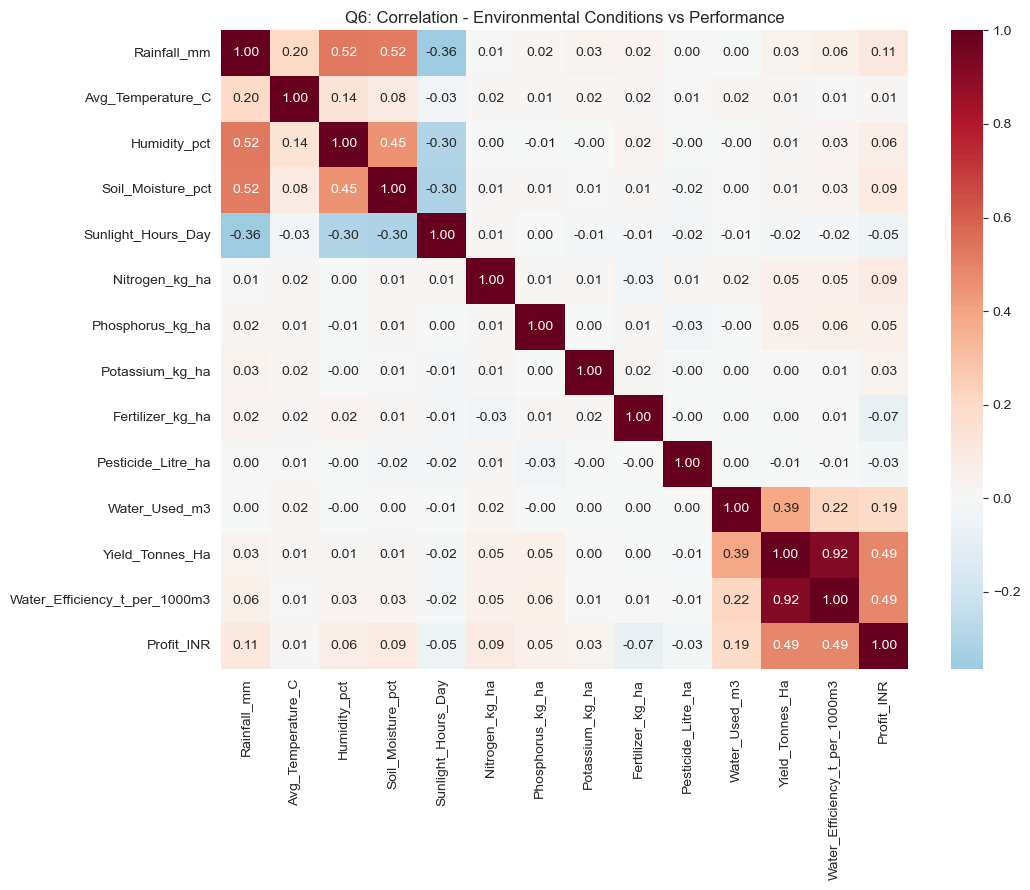

In [10]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
             'Sunlight_Hours_Day', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
             'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Yield_Tonnes_Ha',
             'Water_Efficiency_t_per_1000m3', 'Profit_INR']
corr_matrix = df[corr_cols].corr()
print(corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False))
 
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Q6: Correlation - Environmental Conditions vs Performance')
plt.tight_layout(); plt.show()

        Revenue_INR  Total_Cost_INR  Profit_INR
Season                                         
Kharif     710719.0        531804.0    178915.0
Rabi       601526.0        513837.0     87689.0
Zaid       519172.0        543977.0    -24805.0
ANOVA on Profit across seasons: F=34.29, p=1.71e-15


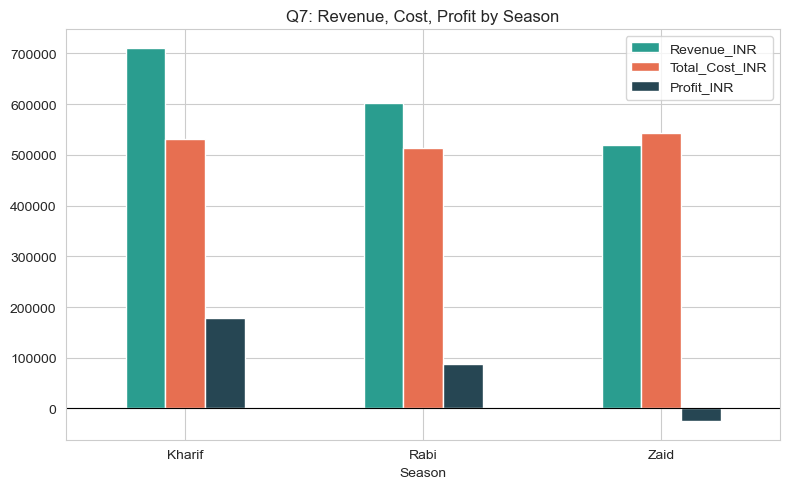

In [11]:
econ_cols = ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
season_econ = df.groupby('Season')[econ_cols].mean().reindex(season_order)
print(season_econ.round(0))
 
f_stat, p_val = stats.f_oneway(*[g['Profit_INR'].values for _, g in df.groupby('Season')])
print(f"ANOVA on Profit across seasons: F={f_stat:.2f}, p={p_val:.2e}")
 
fig, ax = plt.subplots(figsize=(8, 5))
season_econ.plot(kind='bar', ax=ax, color=['#2a9d8f', '#e76f51', '#264653'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Q7: Revenue, Cost, Profit by Season')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
 

In [12]:
profit_by_state_season = df.pivot_table(values='Profit_INR', index='State',
                                         columns='Season', aggfunc='mean')[season_order]
print(profit_by_state_season.round(0))

Season            Kharif      Rabi      Zaid
State                                       
Andhra Pradesh  169316.0   26316.0  -84085.0
Gujarat         217051.0   82846.0 -106930.0
Karnataka       201226.0   70953.0   23311.0
Madhya Pradesh  134242.0   61576.0     210.0
Maharashtra     168801.0  159582.0  -40598.0
Punjab          133779.0  169295.0   62110.0
Tamil Nadu      211304.0   70457.0  -15175.0
Telangana       199668.0   62825.0  -34621.0



States following Kharif > Rabi > Zaid profit pattern: 7 / 8


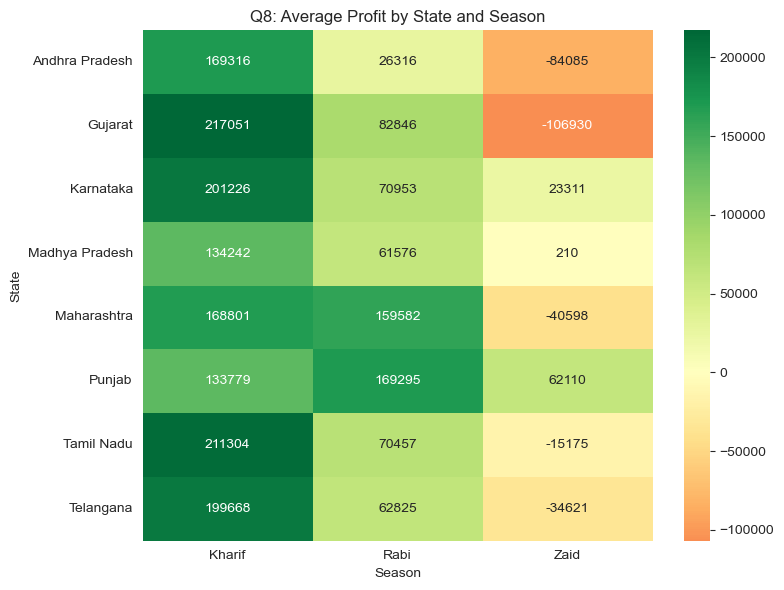

In [13]:
ranking_matches = (profit_by_state_season['Kharif'] > profit_by_state_season['Rabi']) & \
                   (profit_by_state_season['Rabi'] > profit_by_state_season['Zaid'])
print(f"\nStates following Kharif > Rabi > Zaid profit pattern: "
      f"{ranking_matches.sum()} / {len(ranking_matches)}")
 
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(profit_by_state_season, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Q8: Average Profit by State and Season')
plt.tight_layout(); plt.show()
 

In [14]:
f_yield, p_yield = stats.f_oneway(*[g['Yield_Tonnes_Ha'].values for _, g in df.groupby('Season')])
f_profit, p_profit = stats.f_oneway(*[g['Profit_INR'].values for _, g in df.groupby('Season')])
print(f"Yield across seasons  -> F={f_yield:.2f}, p={p_yield:.3f} "
      f"({'significant' if p_yield < 0.05 else 'NOT significant'})")
print(f"Profit across seasons -> F={f_profit:.2f}, p={p_profit:.2e} "
      f"({'significant' if p_profit < 0.05 else 'NOT significant'})")
print("\n=> Unusual pattern: profit differs significantly across seasons while yield does not,")
print("   meaning the profit gap is driven by price/revenue effects, not physical output.")
 
print("\nDisease/Pest risk by season (highest in the season with highest rainfall):")
print(df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(season_order).round(1))

Yield across seasons  -> F=nan, p=nan (NOT significant)
Profit across seasons -> F=34.29, p=1.71e-15 (significant)

=> Unusual pattern: profit differs significantly across seasons while yield does not,
   meaning the profit gap is driven by price/revenue effects, not physical output.

Disease/Pest risk by season (highest in the season with highest rainfall):
Season
Kharif    54.5
Rabi      40.5
Zaid      38.2
Name: Disease_Pest_Risk_pct, dtype: float64


In [16]:
best_season_profit = season_econ['Profit_INR'].idxmax()
worst_season_profit = season_econ['Profit_INR'].idxmin()
strongest_yield_driver = corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').abs().idxmax()
loss_pct_by_season = (df.groupby('Season')['Profit_INR'].apply(lambda x: (x < 0).mean()) * 100).reindex(season_order)
 
print(f"Insight 1: '{best_season_profit}' is the most profitable season on average "
      f"(₹{season_econ.loc[best_season_profit, 'Profit_INR']:,.0f}/farm).")
print(f"Insight 2: '{worst_season_profit}' is the weakest season "
      f"(₹{season_econ.loc[worst_season_profit, 'Profit_INR']:,.0f}/farm), "
      f"with {loss_pct_by_season[worst_season_profit]:.1f}% of farms operating at a loss.")
print(f"Insight 3: The strongest correlate of yield is '{strongest_yield_driver}' "
      f"(r={corr_matrix['Yield_Tonnes_Ha'][strongest_yield_driver]:.2f}).")
print(f"Insight 4: Yield differs across seasons with p={p_yield:.3f} but profit differs "
      f"with p={p_profit:.2e} -> economic, not agronomic, factors drive the seasonal gap.")

Insight 1: 'Kharif' is the most profitable season on average (₹178,915/farm).
Insight 2: 'Zaid' is the weakest season (₹-24,805/farm), with 64.5% of farms operating at a loss.
Insight 3: The strongest correlate of yield is 'Water_Efficiency_t_per_1000m3' (r=0.92).
Insight 4: Yield differs across seasons with p=nan but profit differs with p=1.71e-15 -> economic, not agronomic, factors drive the seasonal gap.


In [18]:
input_corr = corr_matrix.loc[['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
                               'Fertilizer_kg_ha', 'Rainfall_mm'], 'Yield_Tonnes_Ha']
crop_yield_range = df.groupby('Crop')['Yield_Tonnes_Ha'].mean()
crop_effect_size = crop_yield_range.max() - crop_yield_range.min()
 
print("Conclusion 1: Classical inputs (N, P, K, fertilizer, rainfall) show weak correlation with "
      f"yield (|r| all below {input_corr.abs().max():.2f}), so input intensity alone does not "
      "explain yield differences in this dataset.")
print(f"Conclusion 2: Crop choice has a much larger effect — average yield spans "
      f"{crop_effect_size:.1f} t/ha across crop types (Sugarcane vs Pulses), dwarfing any "
      "seasonal or input-driven effect.")
print(f"Conclusion 3: Season materially affects profitability (p={p_profit:.2e}) even though it "
      f"does not materially affect yield (p={p_yield:.3f}) — pointing to price/market dynamics, "
      "not production capacity, as the main seasonal risk factor.")
 

Conclusion 1: Classical inputs (N, P, K, fertilizer, rainfall) show weak correlation with yield (|r| all below 0.05), so input intensity alone does not explain yield differences in this dataset.
Conclusion 2: Crop choice has a much larger effect — average yield spans 46.0 t/ha across crop types (Sugarcane vs Pulses), dwarfing any seasonal or input-driven effect.
Conclusion 3: Season materially affects profitability (p=1.71e-15) even though it does not materially affect yield (p=nan) — pointing to price/market dynamics, not production capacity, as the main seasonal risk factor.


In [19]:
zaid_states_at_loss = profit_by_state_season[profit_by_state_season['Zaid'] < 0].index.tolist()
top_water_efficiency_season = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().idxmax()
highest_risk_season = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().idxmax()
 
print(f"Planning implication 1: States where Zaid is loss-making on average "
      f"({', '.join(zaid_states_at_loss)}) are priority candidates for Zaid-season market "
      "linkage or crop-mix review.")
print(f"Planning implication 2: '{top_water_efficiency_season}' has the best water-use "
      "efficiency and can serve as a benchmark for irrigation practice in other seasons.")
print(f"Planning implication 3: '{highest_risk_season}' has the highest disease/pest risk "
      f"({df.groupby('Season')['Disease_Pest_Risk_pct'].mean().max():.1f}%) and should receive "
      "prioritized pest-management resource allocation, since it is also the most profitable "
      "season and worth protecting.")

Planning implication 1: States where Zaid is loss-making on average (Andhra Pradesh, Gujarat, Maharashtra, Tamil Nadu, Telangana) are priority candidates for Zaid-season market linkage or crop-mix review.
Planning implication 2: 'Kharif' has the best water-use efficiency and can serve as a benchmark for irrigation practice in other seasons.
Planning implication 3: 'Kharif' has the highest disease/pest risk (54.5%) and should receive prioritized pest-management resource allocation, since it is also the most profitable season and worth protecting.
